## Oil Market Risk Management (Part 1)

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import yfinance as yf
import logging, io, contextlib
from pathlib import Path
from matplotlib.ticker import MaxNLocator


from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
FIGSIZE = (11,6)

C = {"wti": "#1f4e79", "brent": "#c55a11", "accent": "#2e9e8f", "warn": "#c0392b",
     "muted": "#7f8c8d", "purple": "#6c5ce7", "green": "#27ae60"}
SEQ = [C["wti"], C["brent"], C["accent"], C["warn"], C["purple"], C["green"], C["muted"]]

mpl.rcParams.update({
    "figure.figsize": FIGSIZE, "figure.dpi": 120, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.labelweight": "medium", "axes.grid": True,
    "grid.alpha": 0.22, "grid.linestyle": "--", "axes.edgecolor": "#4d4d4d",
    "axes.linewidth": 0.9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": mpl.cycler(color=SEQ), "legend.frameon": False,
    "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "figure.autolayout": True,
})

def style_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.tick_params(length=0)
    return ax

print("Environment ready. Pandas", pd.__version__, "| NumPy", np.__version__,
      "| Matplotlib", mpl.__version__)

Environment ready. Pandas 2.2.2 | NumPy 2.0.2 | Matplotlib 3.10.0


## Data Import and Structuring

In [3]:
from dateutil.relativedelta import MO
MONTH_START = "2000-01-01"
MONTH_END   = "2023-09-01"
DAILY_START = "2000-01-01"
DAILY_END   = "2023-12-31"

DATA = Path("data")

FRED_CPI_URL = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv"
    "?id=CPIAUCSL"
)

logging.getLogger("yfinance").setLevel(logging.CRITICAL)

TICKERS = {"WTI": "CL=F", "Brent": "BZ=F", "NatGas": "NG=F",
           "SP500": "^GSPC", "LongRate": "^TNX"}
CACHE = DATA / "yf_cache"

def yf_close(label, start=DAILY_START, end=DAILY_END):
    ticker = TICKERS[label]
    try:
        with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
            df = yf.download(ticker, start=start, end=end, progress=False,
                             auto_adjust=True, threads=False)
        close = df["Close"]
        if hasattr(close, "columns"):
            close = close.iloc[:, 0]
        close = close.dropna()
        if len(close) == 0:
            raise ValueError("empty response")
        src = "Yahoo Finance (live)"
    except Exception:
        c = pd.read_csv(CACHE / f"{label}.csv", parse_dates=["Date"]).set_index("Date")
        close = c["Close"].loc[start:end].dropna()
        src = "yfinance cache (offline)"
    close.name = label
    print(f"{label:8s} {ticker:7s} -> {len(close):5d} obs [{src}]")
    return close

def load_cpi(start=MONTH_START, end=MONTH_END):
      macro_cache = DATA/"macro_cache"
      cache_file = macro_cache/"CPI.csv"
      macro_cache.mkdir(parents=True, exist_ok=True)
      try:
        raw = pd.read_csv(FRED_CPI_URL)
        if raw.empty:
          raise ValueError("Empty Response")
        date_candidates  = ["observation_date", "DATE", "Date"]
        date_col = next((column for column in date_candidates if column in raw.columns),raw.columns[0])

        value_col = "CPIAUCSL"

        if value_col not in raw.columns:
          raise KeyError(f"{value_col} not in FRED CPI data")

        cpi_df = pd.DataFrame({
            "Date": pd.to_datetime(raw[date_col], errors="coerce"),
            "CPI": pd.to_numeric(raw[value_col], errors="coerce")
        })

        cpi_df = cpi_df.dropna(subset=["Date", "CPI"]).drop_duplicates(subset=['Date'], keep="last").sort_values("Date").reset_index(drop=True)

        if cpi_df.empty:
          raise ValueError("No valid CPI data available")
        cpi_df.to_csv(cache_file, index = False)
        source = "FRED live"

      except Exception as live_error:
        print("Cannot download CPI data from FRED", live_error)

        if not cache_file.exists():
          raise RuntimeError("Cannot download CPI data from Fred and " f"cannot find cache at {cache_file}") from live_error
        cpi_df = pd.read_csv(cache_file, parse_dates=["Date"])

        cpi_df['CPI'] = pd.to_numeric(cpi_df['CPI'], errors='coerce')
        cpi_df = cpi_df.dropna(subset=["Date", "CPI"]).drop_duplicates(subset=['Date'], keep="last").sort_values("Date")

        source = "local CPI cache"
      cpi = cpi_df.set_index("Date")["CPI"].sort_index()

      cpi = cpi.loc[pd.Timestamp(start):pd.Timestamp(end)]

      if cpi.empty:
        raise ValueError("Dont have valid data from " f"{start} to {end}")

      cpi.name = "CPI"

      print(f"CPI CPIAUCSL -> " f"{len(cpi):5d} obs [{source}]")

      return cpi

print("Fetching market series via yfinance (CL=F, BZ=F, NG=F, ^GSPC, ^TNX):")
wti_d = yf_close("WTI").to_frame()
brent_d = yf_close("Brent").to_frame()

daily = wti_d.join(brent_d, how="outer").loc[DAILY_START:DAILY_END]
print("\nDaily price panel:", daily.shape, "from",
      daily.index.min().date(), "to", daily.index.max().date())
daily.tail(3)

print("Data sources by role")
print("Financial (yfinance): WTI=CL=F, Brent=BZ=F, NatGas=NG=F, SP500=^GSPC, LongRate=^TNX")
print("Macro (FRED/BLS): CPI=CPIAUCSL genuine; IndProd=INDPRO and GeoRisk=GPR are proxies")
print("Physical (EIA STEO, proxies): OPEC and non-OPEC supply, OECD and non-OECD demand, inventories")
print("CPI is downloaded directly from FRED; other unavailable variables use seeded proxies.")

def to_monthly(series):
    return series.resample("MS").mean()

ng_close = yf_close("NatGas")
sp_close = yf_close("SP500")
tnx_close = yf_close("LongRate")

idx = pd.date_range(MONTH_START, MONTH_END, freq="MS")
real = pd.DataFrame(index=idx)
real["WTI"] = to_monthly(daily["WTI"]).reindex(idx)
real["Brent"] = to_monthly(daily["Brent"]).reindex(idx)
real["NatGas"] = to_monthly(ng_close).reindex(idx)
real["SP500"] = to_monthly(sp_close).reindex(idx)
real["LongRate"] = to_monthly(tnx_close).reindex(idx)

cpi = load_cpi(MONTH_START, MONTH_END)
real["CPI"] = cpi.reindex(idx)

print("Monthly market and macro block:", real.shape)
real.head(3)

Fetching market series via yfinance (CL=F, BZ=F, NG=F, ^GSPC, ^TNX):
WTI      CL=F    ->  5863 obs [Yahoo Finance (live)]
Brent    BZ=F    ->  4081 obs [Yahoo Finance (live)]

Daily price panel: (5864, 2) from 2000-08-23 to 2023-12-29
Data sources by role
Financial (yfinance): WTI=CL=F, Brent=BZ=F, NatGas=NG=F, SP500=^GSPC, LongRate=^TNX
Macro (FRED/BLS): CPI=CPIAUCSL genuine; IndProd=INDPRO and GeoRisk=GPR are proxies
Physical (EIA STEO, proxies): OPEC and non-OPEC supply, OECD and non-OECD demand, inventories
CPI is downloaded directly from FRED; other unavailable variables use seeded proxies.
NatGas   NG=F    ->  5860 obs [Yahoo Finance (live)]
SP500    ^GSPC   ->  6037 obs [Yahoo Finance (live)]
LongRate ^TNX    ->  6031 obs [Yahoo Finance (live)]
CPI CPIAUCSL ->   285 obs [FRED live]
Monthly market and macro block: (285, 6)


,WTI,Brent,NatGas,SP500,LongRate,CPI
2000-01-01,NaN,NaN,NaN,"1,425.5855",6.6472,169.3000
2000-02-01,NaN,NaN,NaN,"1,388.8745",6.5176,170.0000
2000-03-01,NaN,NaN,NaN,"1,442.2126",6.2468,171.0000


In [4]:
print("Reconstructing physical-market and macro proxy series with a fixed seed (660).")
print("Each series is anchored to documented episodes: 2008 crisis, 2014-16 glut,")
print("2020 demand collapse and OPEC+ cut, and the 2022 supply shock.")

rng = np.random.default_rng(660)
n = len(idx)
t = np.arange(n)
yr = idx.year + (idx.month - 1) / 12.0

def bump(centre, width, height):
    return height * np.exp(-((yr - centre) ** 2) / (2 * width ** 2))

wti_real = real["WTI"].to_numpy()
wti_z = (wti_real - np.nanmean(wti_real)) / np.nanstd(wti_real)
wti_z = pd.Series(wti_z).ffill().bfill().to_numpy()
wti_lag = pd.Series(wti_z).rolling(12, min_periods=1).mean().shift(6).bfill().to_numpy()

proxy = pd.DataFrame(index=idx)

ip = (88 + 0.055 * t
      - 6.0 * bump(2001.8, 0.6, 1)
      - 14.0 * bump(2009.0, 0.9, 1)
      - 16.0 * bump(2020.3, 0.35, 1)
      + 10.0 * bump(2021.5, 0.7, 1))
proxy["IndProd"] = ip + rng.normal(0, 0.6, n)

gpr = (90
       + 70 * bump(2001.7, 0.20, 1)
       + 55 * bump(2003.2, 0.25, 1)
       + 35 * bump(2011.2, 0.40, 1)
       + 40 * bump(2014.2, 0.30, 1)
       + 30 * bump(2015.9, 0.25, 1)
       + 45 * bump(2019.7, 0.20, 1)
       + 130 * bump(2022.1, 0.25, 1))
proxy["GeoRisk"] = np.maximum(gpr + rng.normal(0, 6, n), 40)

opec = (31.5 + 1.2 * np.sin(2 * np.pi * t / 96)
        - 6.0 * bump(2020.4, 0.30, 1)
        + 0.6 * wti_lag)
proxy["OPEC_Supply"] = opec + rng.normal(0, 0.25, n)

nonopec = (45 + 0.045 * t
           + 6.0 / (1 + np.exp(-(t - 132) / 18))
           - 4.0 * bump(2020.4, 0.30, 1)
           + 1.4 * wti_lag)
proxy["NonOPEC_Supply"] = nonopec + rng.normal(0, 0.35, n)

oecd_d = (47.5 - 0.004 * t
          - 1.2 * bump(2009.0, 0.8, 1)
          - 7.0 * bump(2020.4, 0.28, 1))
proxy["OECD_Demand"] = oecd_d + rng.normal(0, 0.3, n)

nonoecd_d = (30 + 0.075 * t
             - 4.5 * bump(2020.4, 0.30, 1))
proxy["NonOECD_Demand"] = nonoecd_d + rng.normal(0, 0.35, n)

gap = (proxy["OPEC_Supply"] + proxy["NonOPEC_Supply"]
       - proxy["OECD_Demand"] - proxy["NonOECD_Demand"]).to_numpy()
inv = (2850 + np.cumsum(gap - np.mean(gap)) * 4 - 60 * wti_lag)
proxy["OECD_Inventory"] = inv + rng.normal(0, 12, n)

print("Proxy block:", proxy.shape)
proxy.head(3)

Reconstructing physical-market and macro proxy series with a fixed seed (660).
Each series is anchored to documented episodes: 2008 crisis, 2014-16 glut,
2020 demand collapse and OPEC+ cut, and the 2022 supply shock.
Proxy block: (285, 7)


,IndProd,GeoRisk,OPEC_Supply,NonOPEC_Supply,OECD_Demand,NonOECD_Demand,OECD_Inventory
2000-01-01,87.4785,81.6560,30.5420,43.2674,47.4454,29.8030,"2,913.1049"
2000-02-01,86.9345,98.9852,30.5550,43.7175,47.4516,30.0987,"2,886.1079"
2000-03-01,87.2962,91.0087,30.7280,43.6649,47.0558,30.3254,"2,896.1485"


In [5]:
master = real.join(proxy)
master["WTI_Brent_Spread"] = master["WTI"] - master["Brent"]

ROLE = {
    "Financial": ["WTI", "Brent", "WTI_Brent_Spread", "SP500", "NatGas"],
    "Macro/Geopolitical": ["CPI", "LongRate", "IndProd", "GeoRisk"],
    "Microeconomic": ["OPEC_Supply", "NonOPEC_Supply", "OECD_Demand",
                      "NonOECD_Demand", "OECD_Inventory"],
}
ordered = ROLE["Macro/Geopolitical"] + ROLE["Microeconomic"] + ROLE["Financial"]
master = master[ordered]
print("Master monthly dataset:", master.shape)
master.describe().T[["mean", "std", "min", "max"]]

Master monthly dataset: (285, 14)


,mean,std,min,max
CPI,225.5679,33.9603,169.3000,307.2760
LongRate,3.2229,1.3129,0.6155,6.6472
IndProd,94.1472,7.3881,79.2681,112.4994
GeoRisk,100.0917,21.7488,72.5323,214.2423
OPEC_Supply,31.2237,1.3376,24.9499,33.7324
NonOPEC_Supply,54.3104,6.7940,43.0066,65.9780
OECD_Demand,46.6296,1.1453,39.8277,48.1561
NonOECD_Demand,40.5077,6.0572,29.8030,51.4048
OECD_Inventory,"2,560.3908",378.4542,"1,863.6858","3,064.1842"
WTI,63.8333,25.4746,16.6990,134.0157


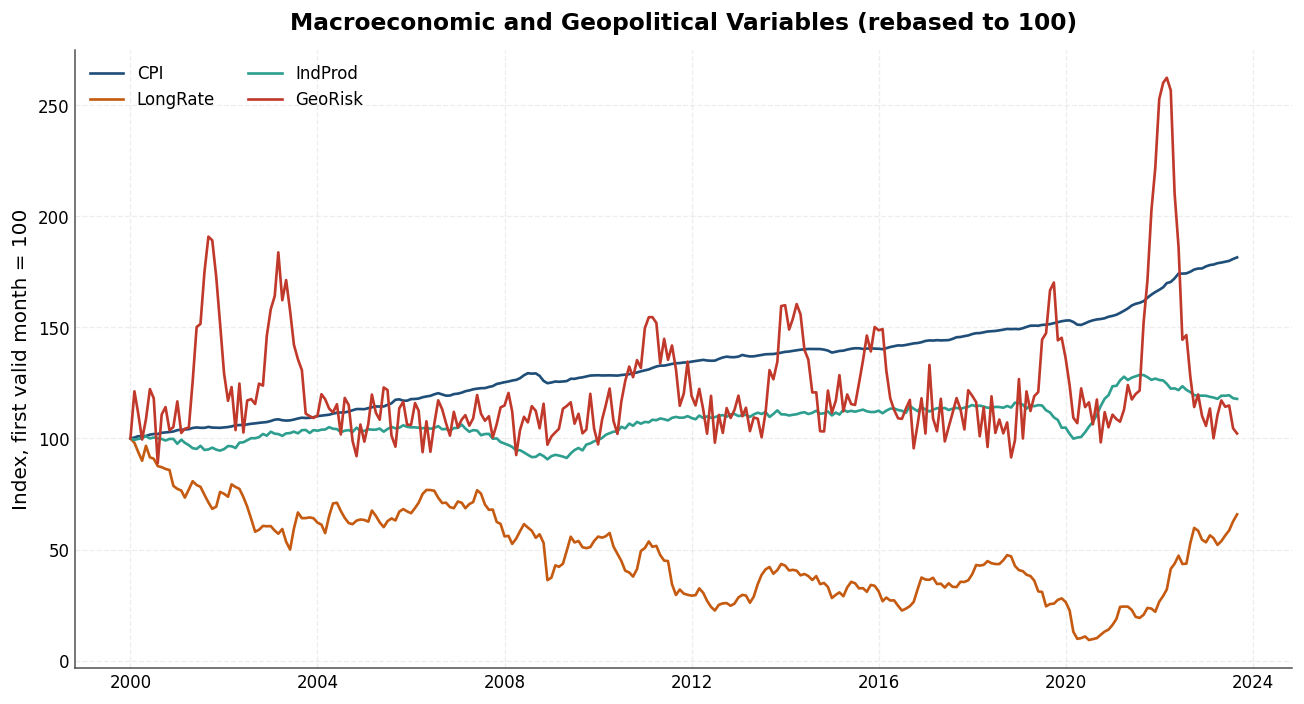

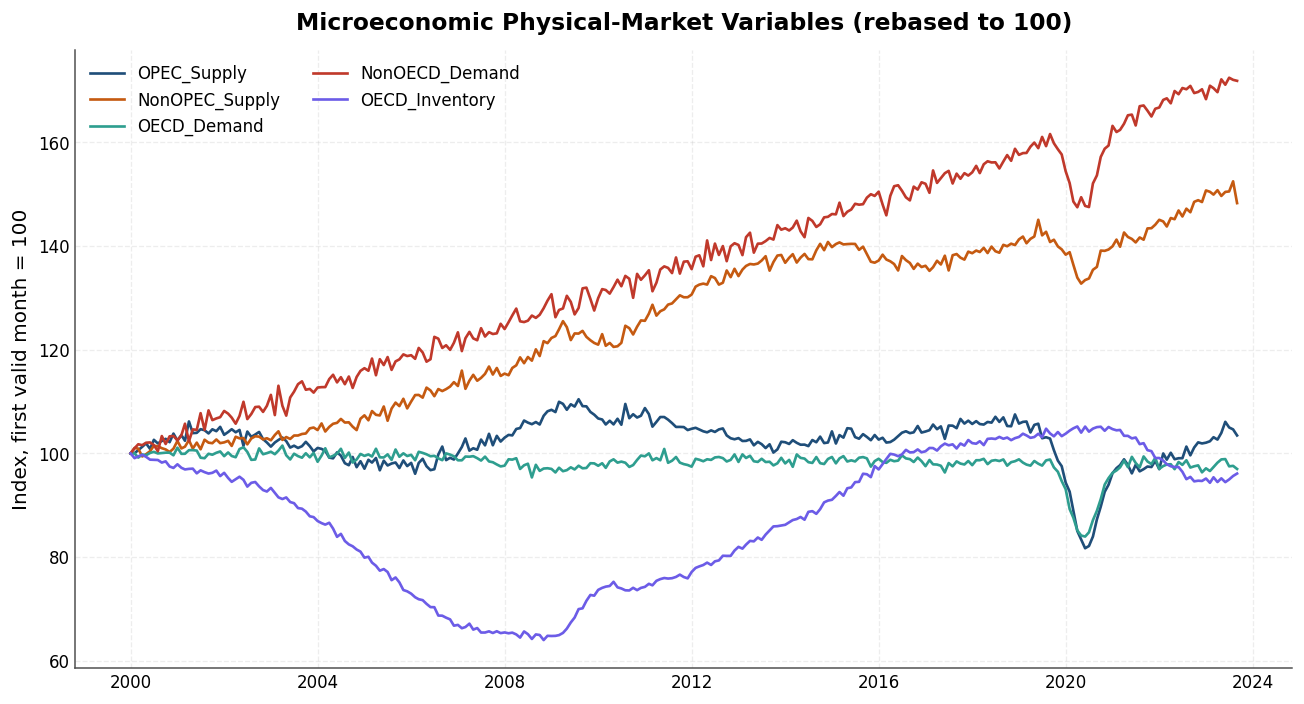

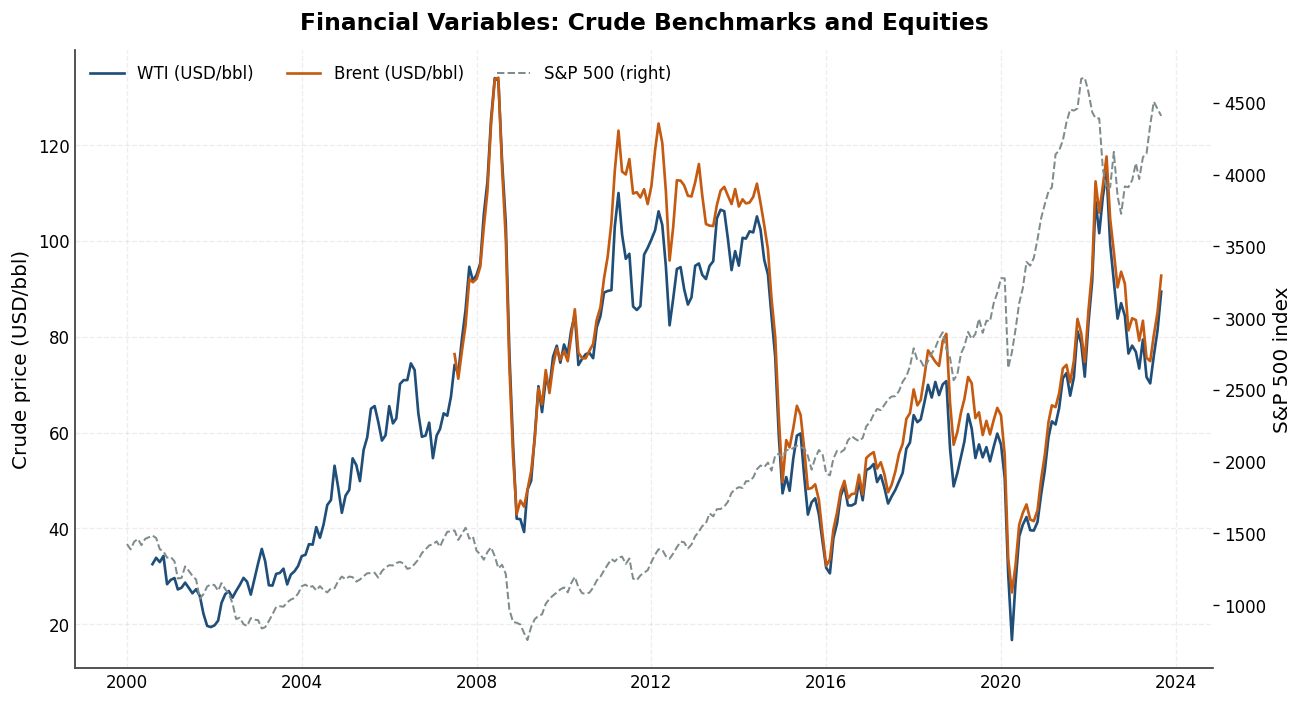

In [6]:
def plot_group(cols, title, normalise=True):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    block = master[cols]
    for col in cols:
        s = block[col].dropna()
        if normalise:
            s = 100 * s / s.iloc[0]
        ax.plot(s.index, s.values, lw=1.6, label=col)
    ylab = "Index, first valid month = 100" if normalise else "Level"
    style_axis(ax, title, "", ylab)
    ax.legend(ncol=2, loc="upper left")
    plt.show()

plot_group(ROLE["Macro/Geopolitical"], "Macroeconomic and Geopolitical Variables (rebased to 100)")

plot_group(ROLE["Microeconomic"], "Microeconomic Physical-Market Variables (rebased to 100)")


fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(master.index, master["WTI"],   color=C["wti"],   lw=1.6, label="WTI (USD/bbl)")
ax.plot(master.index, master["Brent"], color=C["brent"], lw=1.6, label="Brent (USD/bbl)")
ax2 = ax.twinx()
ax2.plot(master.index, master["SP500"], color=C["muted"], lw=1.2, ls="--",
         label="S&P 500 (right)")
ax2.set_ylabel("S&P 500 index")
ax2.grid(False)
style_axis(ax, "Financial Variables: Crude Benchmarks and Equities", "",
           "Crude price (USD/bbl)")
l1, lab1 = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lab1 + lab2, loc="upper left", ncol=3)
plt.show()

## Data Dictionary

In [7]:
meta = [
    ("WTI", "West Texas Intermediate crude price", "Financial", "USD/barrel", "Monthly", "Yahoo Finance CL=F via yfinance"),
    ("Brent", "Brent crude price", "Financial", "USD/barrel", "Monthly", "Yahoo Finance BZ=F via yfinance"),
    ("WTI_Brent_Spread", "WTI minus Brent price differential", "Financial", "USD/barrel", "Monthly", "Derived"),
    ("SP500", "S&P 500 equity index level", "Financial", "Index points", "Monthly", "Yahoo Finance ^GSPC via yfinance"),
    ("NatGas", "Henry Hub natural gas price", "Financial", "USD/MMBtu", "Monthly", "Yahoo Finance NG=F via yfinance"),
    ("CPI", "US headline Consumer Price Index", "Macro", "Index (1982-84=100)", "Monthly", "FRED/BLS (genuine)"),
    ("LongRate", "Long-term interest rate (10-year)", "Macro", "Percent", "Monthly", "Yahoo Finance ^TNX via yfinance"),
    ("IndProd", "Industrial production index", "Macro", "Index (2017=100)", "Monthly", "FRED INDPRO proxy (reconstructed)"),
    ("GeoRisk", "Geopolitical risk index", "Geopolitical", "Index", "Monthly", "Caldara-Iacoviello GPR proxy (reconstructed)"),
    ("OPEC_Supply", "OPEC crude oil production", "Micro", "Million barrels/day", "Monthly", "EIA STEO proxy (reconstructed)"),
    ("NonOPEC_Supply", "Non-OPEC crude oil production", "Micro", "Million barrels/day", "Monthly", "EIA STEO proxy (reconstructed)"),
    ("OECD_Demand", "OECD petroleum consumption", "Micro", "Million barrels/day", "Monthly", "EIA STEO proxy (reconstructed)"),
    ("NonOECD_Demand", "Non-OECD petroleum consumption", "Micro", "Million barrels/day", "Monthly", "EIA STEO proxy (reconstructed)"),
    ("OECD_Inventory", "OECD commercial crude inventories", "Micro", "Million barrels", "Monthly", "EIA STEO PASC_OECD_T3 proxy (reconstructed)"),
]
dd = pd.DataFrame(meta, columns=["Variable", "Description", "Role", "Unit",
                                 "Frequency", "Source"])
cov = []
for v in dd["Variable"]:
    s = master[v]
    valid = s.dropna()
    cov.append((valid.index.min().strftime("%Y-%m"),
                valid.index.max().strftime("%Y-%m"),
                int(s.isna().sum())))
dd[["Start", "End", "Missing"]] = pd.DataFrame(cov, index=dd.index)
dd


,Variable,Description,Role,Unit,Frequency,Source,Start,End,Missing
0,WTI,West Texas Intermediate crude price,Financial,USD/barrel,Monthly,Yahoo Finance CL=F via yfinance,2000-08,2023-09,7
1,Brent,Brent crude price,Financial,USD/barrel,Monthly,Yahoo Finance BZ=F via yfinance,2007-07,2023-09,90
2,WTI_Brent_Spread,WTI minus Brent price differential,Financial,USD/barrel,Monthly,Derived,2007-07,2023-09,90
3,SP500,S&P 500 equity index level,Financial,Index points,Monthly,Yahoo Finance ^GSPC via yfinance,2000-01,2023-09,0
4,NatGas,Henry Hub natural gas price,Financial,USD/MMBtu,Monthly,Yahoo Finance NG=F via yfinance,2000-08,2023-09,7
5,CPI,US headline Consumer Price Index,Macro,Index (1982-84=100),Monthly,FRED/BLS (genuine),2000-01,2023-09,0
6,LongRate,Long-term interest rate (10-year),Macro,Percent,Monthly,Yahoo Finance ^TNX via yfinance,2000-01,2023-09,0
7,IndProd,Industrial production index,Macro,Index (2017=100),Monthly,FRED INDPRO proxy (reconstructed),2000-01,2023-09,0
8,GeoRisk,Geopolitical risk index,Geopolitical,Index,Monthly,Caldara-Iacoviello GPR proxy (reconstructed),2000-01,2023-09,0
9,OPEC_Supply,OPEC crude oil production,Micro,Million barrels/day,Monthly,EIA STEO proxy (reconstructed),2000-01,2023-09,0


## Data Cleaning

In [8]:
def modified_z(series):
    x = series.dropna()
    med = x.median()
    mad = (x - med).abs().median()
    mad = mad if mad > 0 else 1e-9
    return 0.6745 * (series - med) / mad

print("Screening daily WTI and Brent returns with a robust modified z-score (median and MAD).")
daily_ret_simple = daily.pct_change()
zwti = modified_z(daily_ret_simple["WTI"])
THRESH = 8.0
extreme = daily_ret_simple[(zwti.abs() > THRESH)]
print(f"Daily WTI returns flagged as extreme (|z| > {THRESH}): {len(extreme)}")
print("\nMost extreme WTI return days:")
top = zwti.abs().sort_values(ascending=False).head(5).index
print(daily.loc[top].assign(WTI_return=daily_ret_simple["WTI"].loc[top]))
print(f"\nGlobal WTI price range: min = {daily['WTI'].min():.2f}, "
      f"max = {daily['WTI'].max():.2f} USD/bbl")
print("The minimum is the genuine 2020 sub-zero settlement, kept as a documented event.")

Screening daily WTI and Brent returns with a robust modified z-score (median and MAD).
Daily WTI returns flagged as extreme (|z| > 8.0): 14

Most extreme WTI return days:
                WTI   Brent  WTI_return
Date                                   
2020-04-20 -37.6300 25.5700     -3.0597
2020-04-21  10.0100 19.3300     -1.2660
2020-04-22  13.7800 20.3700      0.3766
2020-04-30  18.8400 25.2700      0.2510
2020-03-09  31.1300 34.3600     -0.2459

Global WTI price range: min = -37.63, max = 145.29 USD/bbl
The minimum is the genuine 2020 sub-zero settlement, kept as a documented event.


In [9]:
def stale_runs(series, min_len=5):
    s = series.dropna()
    grp = (s != s.shift()).cumsum()
    sizes = s.groupby(grp).transform("size")
    return s[sizes >= min_len]

print("Checking duplicates, non-positive prices, and stale repeated runs.")
dup_count = daily.index.duplicated().sum()
nonpos = daily[(daily["WTI"] <= 0) | (daily["Brent"] <= 0)]
stale_wti = stale_runs(daily["WTI"])

print(f"Duplicated daily dates            : {dup_count}")
print(f"Non-positive price observations   : {len(nonpos)}")
if len(nonpos):
    print(nonpos)
print(f"Stale WTI runs (>=5 equal sessions): {len(stale_wti)}")

Checking duplicates, non-positive prices, and stale repeated runs.
Duplicated daily dates            : 0
Non-positive price observations   : 1
                WTI   Brent
Date                       
2020-04-20 -37.6300 25.5700
Stale WTI runs (>=5 equal sessions): 0


In [10]:
print("Filling monthly gaps with time-aware interpolation, then nearest-valid carry.")
missing_before = master.isna().sum()
print("Missing values per variable before imputation:")
print(missing_before[missing_before > 0] if missing_before.sum()
      else "None in the assembled monthly window.")
master_imputed = master.interpolate(method="time", limit_direction="both")
print(f"\nTotal missing values after imputation: {master_imputed.isna().sum().sum()}")

Filling monthly gaps with time-aware interpolation, then nearest-valid carry.
Missing values per variable before imputation:
WTI                  7
Brent               90
WTI_Brent_Spread    90
NatGas               7
dtype: int64

Total missing values after imputation: 0


## Sterilized Dataset and Removal Log

In [11]:
removal_log = []

daily_clean = daily.copy()
neg_mask = (daily_clean["WTI"] <= 0)
for d in daily_clean.index[neg_mask]:
    removal_log.append({
        "scope": "daily WTI",
        "date_or_period": d.strftime("%Y-%m-%d"),
        "action": "excluded from return series",
        "reason": "non-positive settlement (genuine 2020 storage event) breaks log returns",
    })
daily_clean.loc[neg_mask, "WTI"] = np.nan
daily_clean = daily_clean.interpolate(method="time", limit_direction="both")
daily_ret = np.log(daily_clean / daily_clean.shift()).dropna()

master_clean = master_imputed.copy()
for v in master.columns:
    miss = int(master[v].isna().sum())
    if miss:
        removal_log.append({
            "scope": f"monthly {v}",
            "date_or_period": "scattered",
            "action": f"{miss} value(s) imputed",
            "reason": "unreleased or missing monthly figure, filled by time interpolation",
        })

removal_log.append({
    "scope": "all monthly series",
    "date_or_period": "before 2000-01",
    "action": "excluded from modelling window",
    "reason": "pre-2000 coverage is incomplete across the physical-market group",
})

removal_df = pd.DataFrame(removal_log)
print("Sterilized monthly dataset:", master_clean.shape,
      "| Sterilized daily returns:", daily_ret.shape)
removal_df

Sterilized monthly dataset: (285, 14) | Sterilized daily returns: (5863, 2)


,scope,date_or_period,action,reason
0,daily WTI,2020-04-20,excluded from return series,non-positive settlement (genuine 2020 storage ...
1,monthly WTI,scattered,7 value(s) imputed,"unreleased or missing monthly figure, filled b..."
2,monthly Brent,scattered,90 value(s) imputed,"unreleased or missing monthly figure, filled b..."
3,monthly WTI_Brent_Spread,scattered,90 value(s) imputed,"unreleased or missing monthly figure, filled b..."
4,monthly NatGas,scattered,7 value(s) imputed,"unreleased or missing monthly figure, filled b..."
5,all monthly series,before 2000-01,excluded from modelling window,pre-2000 coverage is incomplete across the phy...


## Exploratory Data Analysis

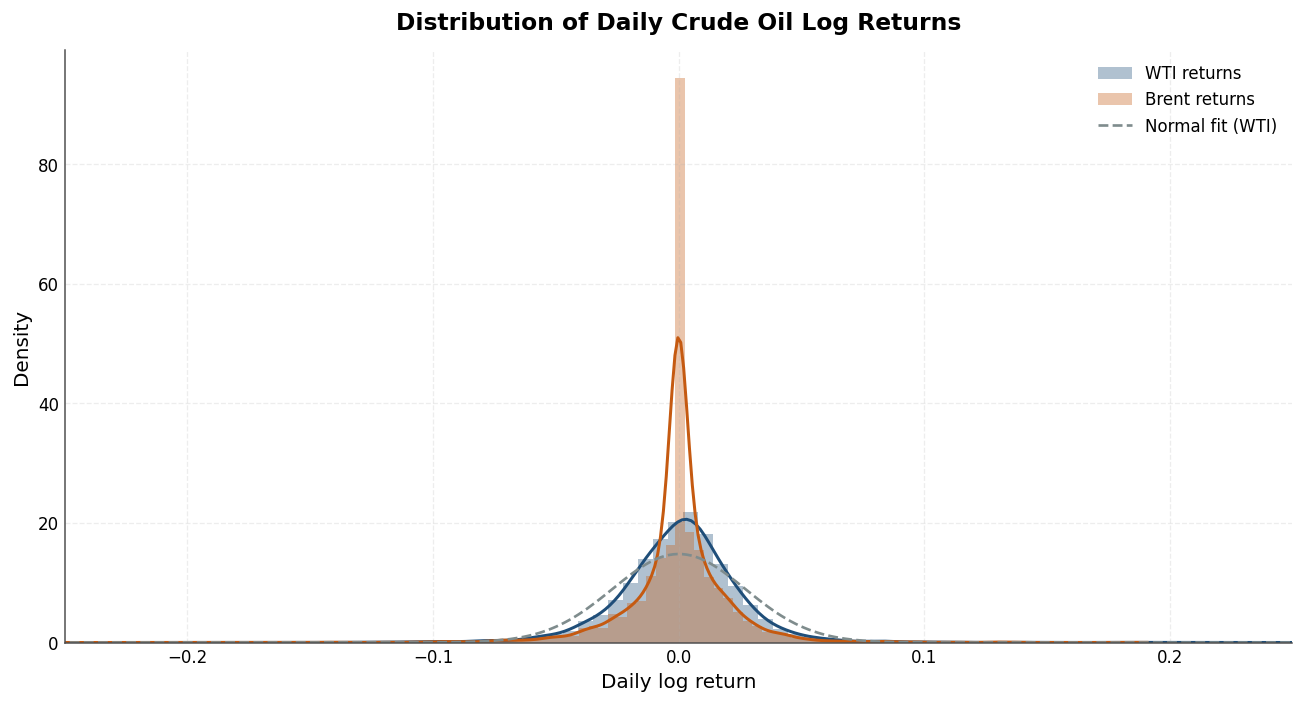

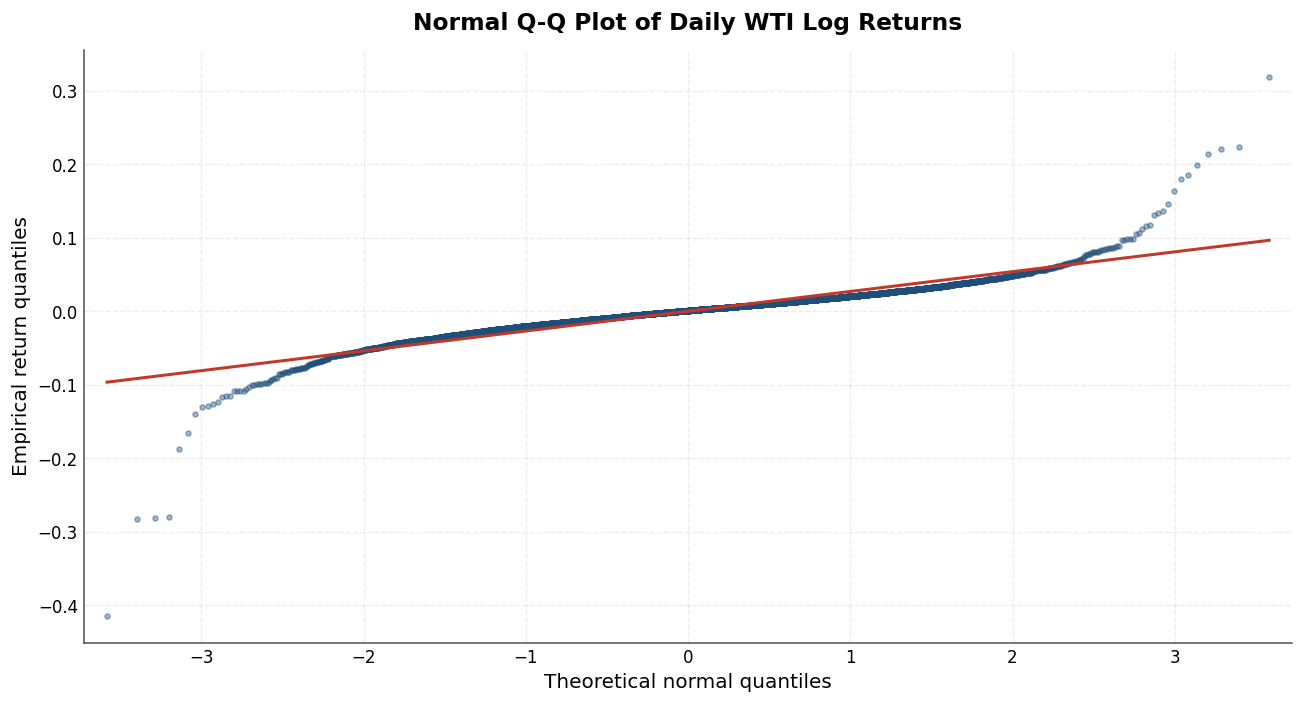

In [12]:
fig, ax = plt.subplots(figsize=FIGSIZE)
for col, colour in [("WTI", C["wti"]), ("Brent", C["brent"])]:
    r = daily_ret[col].values
    ax.hist(r, bins=120, density=True, alpha=0.35, color=colour, label=f"{col} returns")
    xs = np.linspace(r.min(), r.max(), 400)
    kde = stats.gaussian_kde(r)
    ax.plot(xs, kde(xs), color=colour, lw=1.8)
mu, sd = daily_ret["WTI"].mean(), daily_ret["WTI"].std()
xs = np.linspace(daily_ret["WTI"].min(), daily_ret["WTI"].max(), 400)
ax.plot(xs, stats.norm.pdf(xs, mu, sd), color=C["muted"], ls="--", lw=1.6,
        label="Normal fit (WTI)")
ax.set_xlim(-0.25, 0.25)
style_axis(ax, "Distribution of Daily Crude Oil Log Returns",
           "Daily log return", "Density")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=FIGSIZE)
sm.qqplot(daily_ret["WTI"], line="s", ax=ax, markerfacecolor=C["wti"],
          markeredgecolor=C["wti"], alpha=0.4, markersize=3)
ax.get_lines()[1].set_color(C["warn"])
ax.get_lines()[1].set_linewidth(1.8)
style_axis(ax, "Normal Q-Q Plot of Daily WTI Log Returns",
           "Theoretical normal quantiles", "Empirical return quantiles")
plt.show()

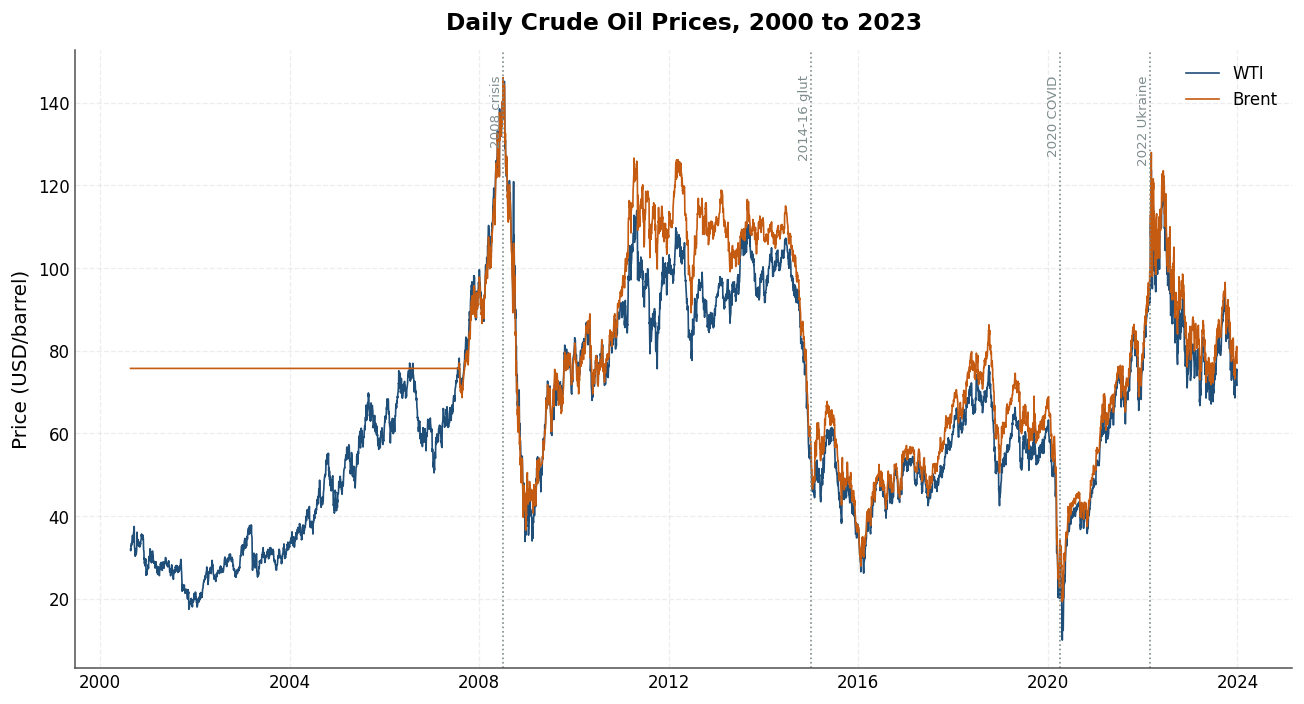

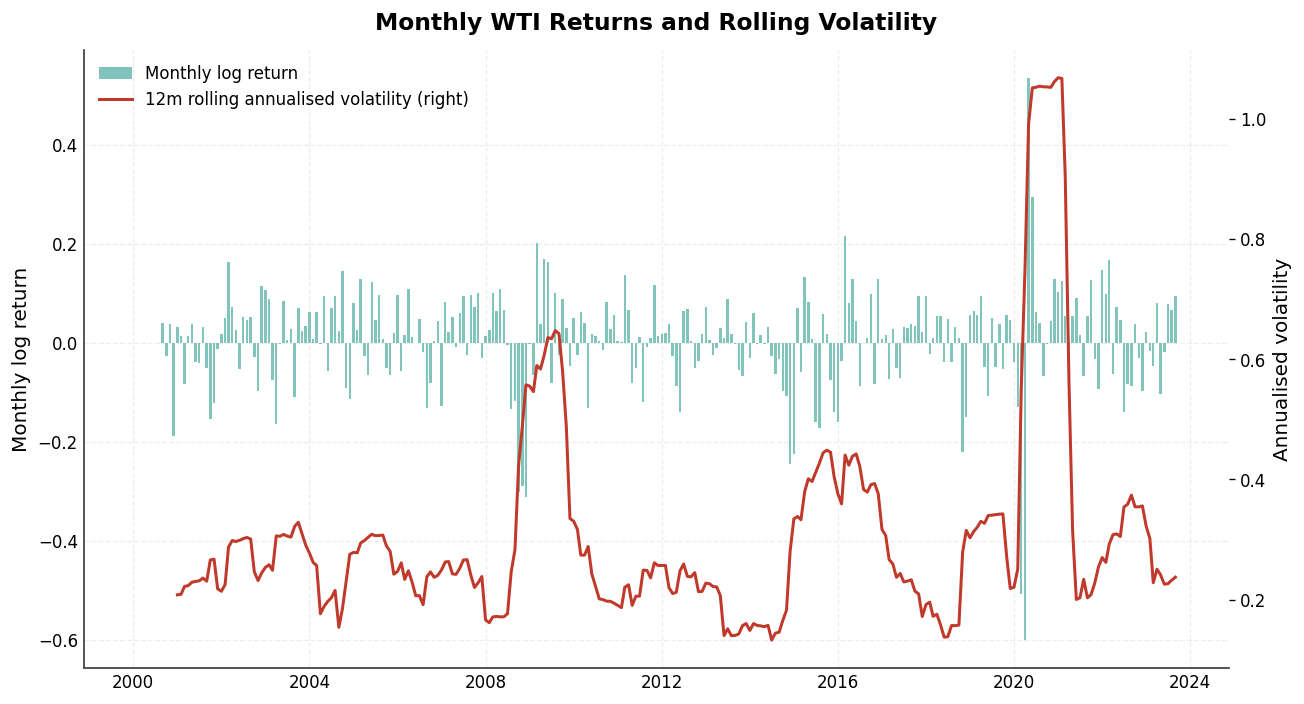

In [13]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(daily_clean.index, daily_clean["WTI"],   color=C["wti"],   lw=1.0, label="WTI")
ax.plot(daily_clean.index, daily_clean["Brent"], color=C["brent"], lw=1.0, label="Brent")
events = {"2008 crisis": "2008-07-01", "2014-16 glut": "2015-01-01",
          "2020 COVID": "2020-04-01", "2022 Ukraine": "2022-03-01"}
for label, d in events.items():
    x = pd.Timestamp(d)
    ax.axvline(x, color=C["muted"], ls=":", lw=1)
    ax.text(x, ax.get_ylim()[1] * 0.96, label, rotation=90,
            va="top", ha="right", fontsize=8, color=C["muted"])
style_axis(ax, "Daily Crude Oil Prices, 2000 to 2023", "", "Price (USD/barrel)")
ax.legend(loc="upper right")
plt.show()



wti_m_ret = np.log(master_clean["WTI"] / master_clean["WTI"].shift()).dropna()
roll_vol = wti_m_ret.rolling(12).std() * np.sqrt(12)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(wti_m_ret.index, wti_m_ret.values, width=20, color=C["accent"],
       alpha=0.6, label="Monthly log return")
ax2 = ax.twinx()
ax2.plot(roll_vol.index, roll_vol.values, color=C["warn"], lw=1.8,
         label="12m rolling annualised volatility (right)")
ax2.grid(False)
ax2.set_ylabel("Annualised volatility")
style_axis(ax, "Monthly WTI Returns and Rolling Volatility", "", "Monthly log return")
l1, lab1 = ax.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lab1 + lab2, loc="upper left")
plt.show()

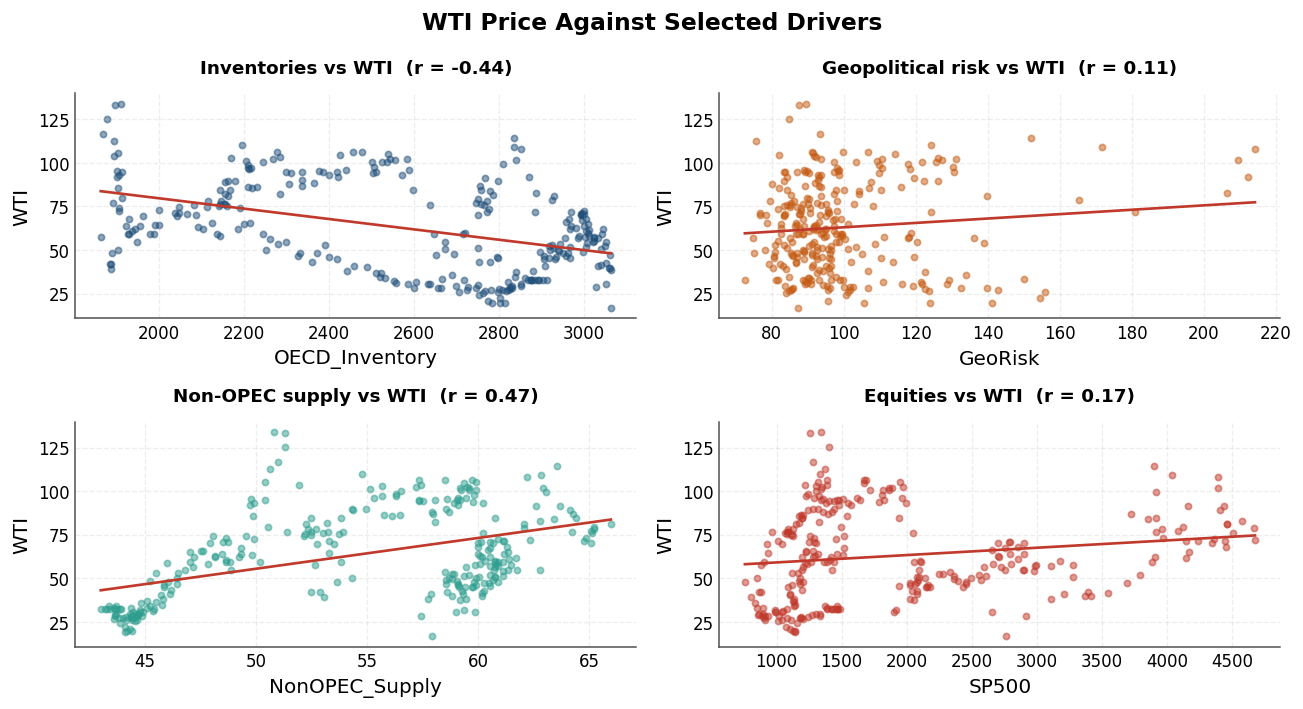

In [14]:
pairs = [("OECD_Inventory", "Inventories vs WTI"),
         ("GeoRisk", "Geopolitical risk vs WTI"),
         ("NonOPEC_Supply", "Non-OPEC supply vs WTI"),
         ("SP500", "Equities vs WTI")]
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE)
for (col, ttl), ax, colour in zip(pairs, axes.ravel(), SEQ):
    ax.scatter(master_clean[col], master_clean["WTI"], s=14, alpha=0.5, color=colour)
    b1, b0 = np.polyfit(master_clean[col], master_clean["WTI"], 1)
    xs = np.linspace(master_clean[col].min(), master_clean[col].max(), 50)
    ax.plot(xs, b0 + b1 * xs, color=C["warn"], lw=1.6)
    r = master_clean[col].corr(master_clean["WTI"])
    ax.set_title(f"{ttl}  (r = {r:.2f})", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("WTI")
    ax.tick_params(length=0)
fig.suptitle("WTI Price Against Selected Drivers", fontsize=14, fontweight="bold")
plt.show()

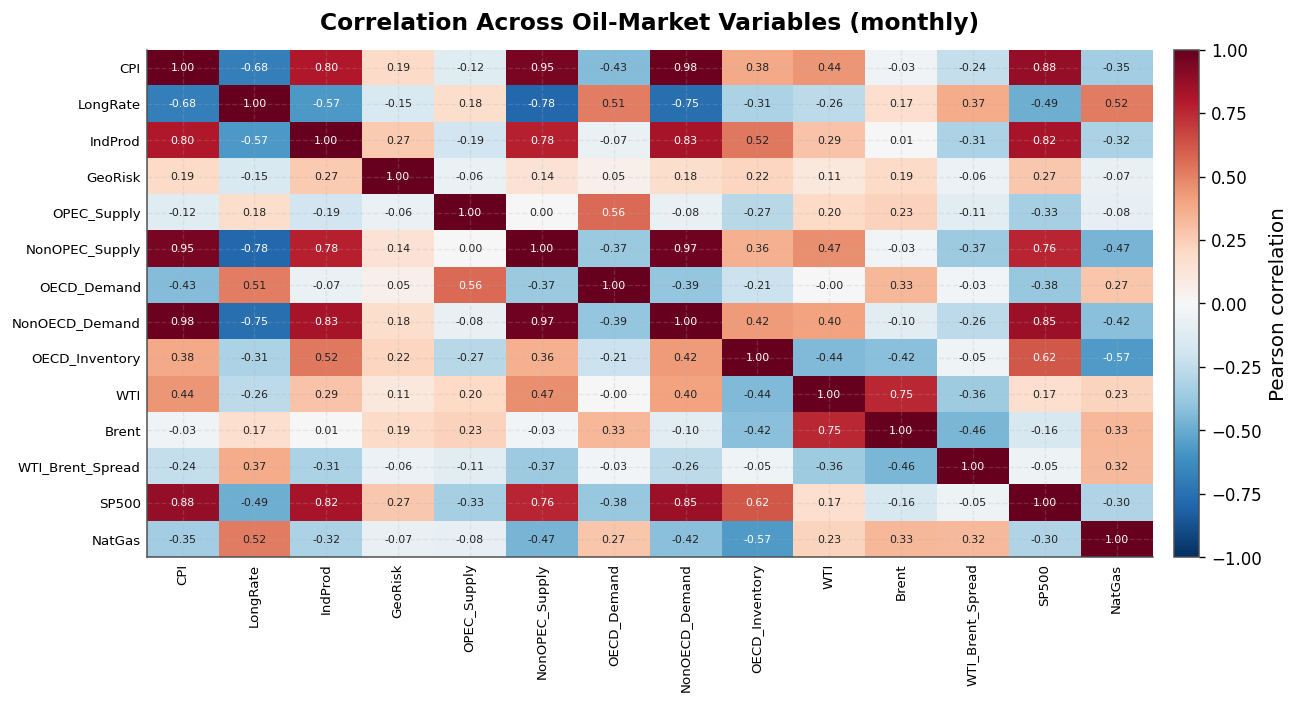

In [15]:
corr = master_clean.corr()
fig, ax = plt.subplots(figsize=FIGSIZE)
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                fontsize=6.5,
                color="white" if abs(corr.values[i, j]) > 0.55 else "#222")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
cb.set_label("Pearson correlation")
style_axis(ax, "Correlation Across Oil-Market Variables (monthly)")
plt.show()

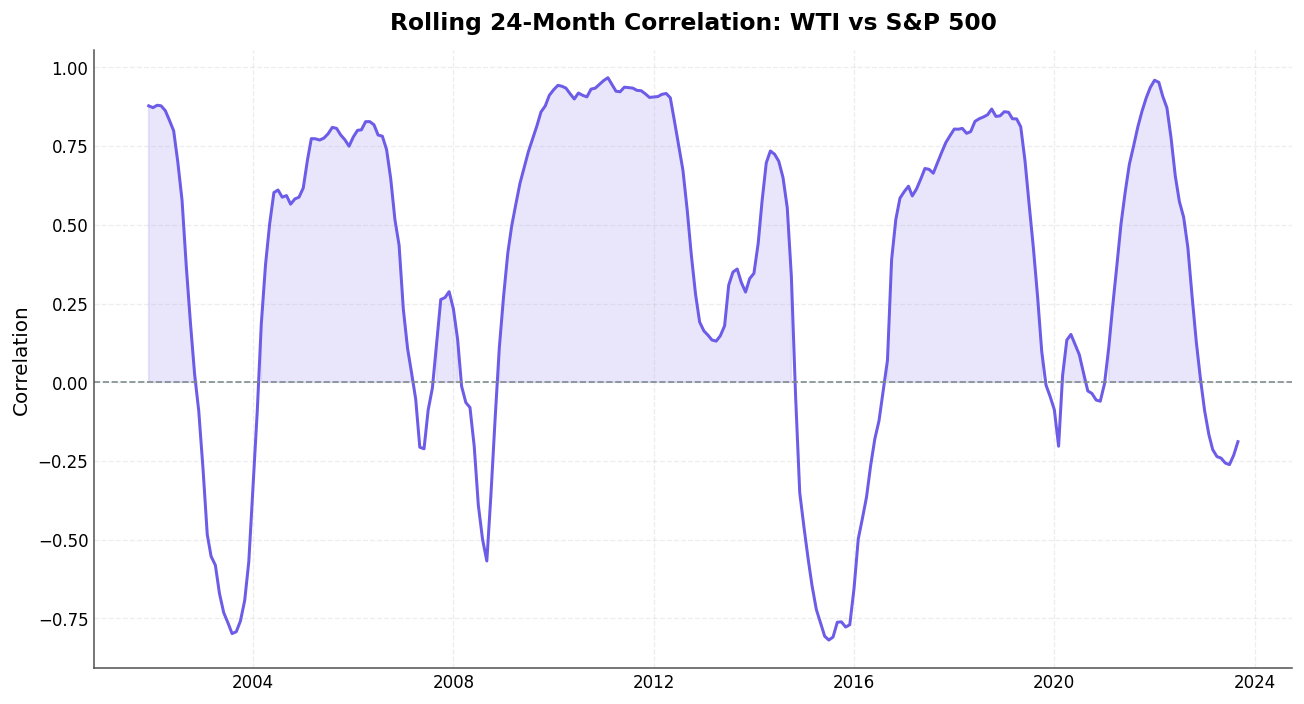

In [16]:
roll_corr = master_clean["WTI"].rolling(24).corr(master_clean["SP500"])
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(roll_corr.index, roll_corr.values, color=C["purple"], lw=1.8)
ax.axhline(0, color=C["muted"], lw=1, ls="--")
ax.fill_between(roll_corr.index, 0, roll_corr.values,
                where=(roll_corr.values >= 0), color=C["purple"], alpha=0.15)
style_axis(ax, "Rolling 24-Month Correlation: WTI vs S&P 500", "", "Correlation")
plt.show()

## About Oil Price

In [17]:
ret = daily_ret["WTI"].values

lb_sq = acorr_ljungbox(ret ** 2, lags=[10], return_df=True)
lb_ret = acorr_ljungbox(ret, lags=[10], return_df=True)
skew = stats.skew(ret)
exkurt = stats.kurtosis(ret)
jb_stat, jb_p = stats.jarque_bera(ret)
adf_price = adfuller(daily_clean["WTI"].dropna())
adf_ret = adfuller(ret)

results = pd.DataFrame({
    "Statistic": [
        "Mean daily return", "Daily volatility", "Annualised volatility",
        "Skewness", "Excess kurtosis", "Jarque-Bera p-value",
        "Ljung-Box p (returns, lag10)", "Ljung-Box p (squared returns, lag10)",
        "ADF p-value (price level)", "ADF p-value (returns)",
    ],
    "Value": [
        ret.mean(), ret.std(), ret.std() * np.sqrt(252),
        skew, exkurt, jb_p,
        lb_ret["lb_pvalue"].iloc[0], lb_sq["lb_pvalue"].iloc[0],
        adf_price[1], adf_ret[1],
    ],
})
results

,Statistic,Value
0,Mean daily return,0.0001
1,Daily volatility,0.0270
2,Annualised volatility,0.4279
3,Skewness,-0.6863
4,Excess kurtosis,24.4325
5,Jarque-Bera p-value,0.0000
6,"Ljung-Box p (returns, lag10)",0.0000
7,"Ljung-Box p (squared returns, lag10)",0.0000
8,ADF p-value (price level),0.0702
9,ADF p-value (returns),0.0000


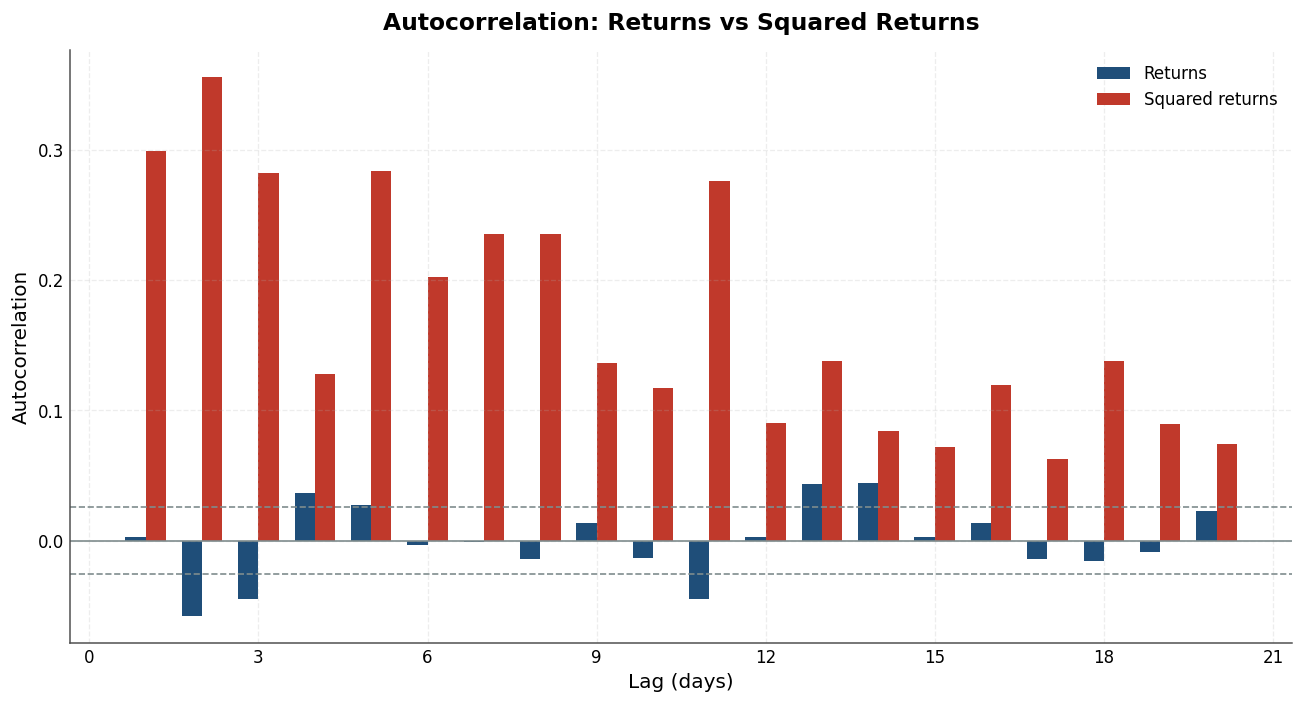

In [18]:
fig, ax = plt.subplots(figsize=FIGSIZE)
lags = np.arange(1, 21)
ax.bar(lags - 0.18, acf(ret, nlags=20)[1:], width=0.36,
       color=C["wti"], label="Returns")
ax.bar(lags + 0.18, acf(ret ** 2, nlags=20)[1:], width=0.36,
       color=C["warn"], label="Squared returns")
ax.axhline(0, color=C["muted"], lw=1)
ci = 1.96 / np.sqrt(len(ret))
ax.axhline(ci, color=C["muted"], ls="--", lw=1)
ax.axhline(-ci, color=C["muted"], ls="--", lw=1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
style_axis(ax, "Autocorrelation: Returns vs Squared Returns", "Lag (days)",
           "Autocorrelation")
ax.legend()
plt.show()

Discretised regime frame: (285, 8)


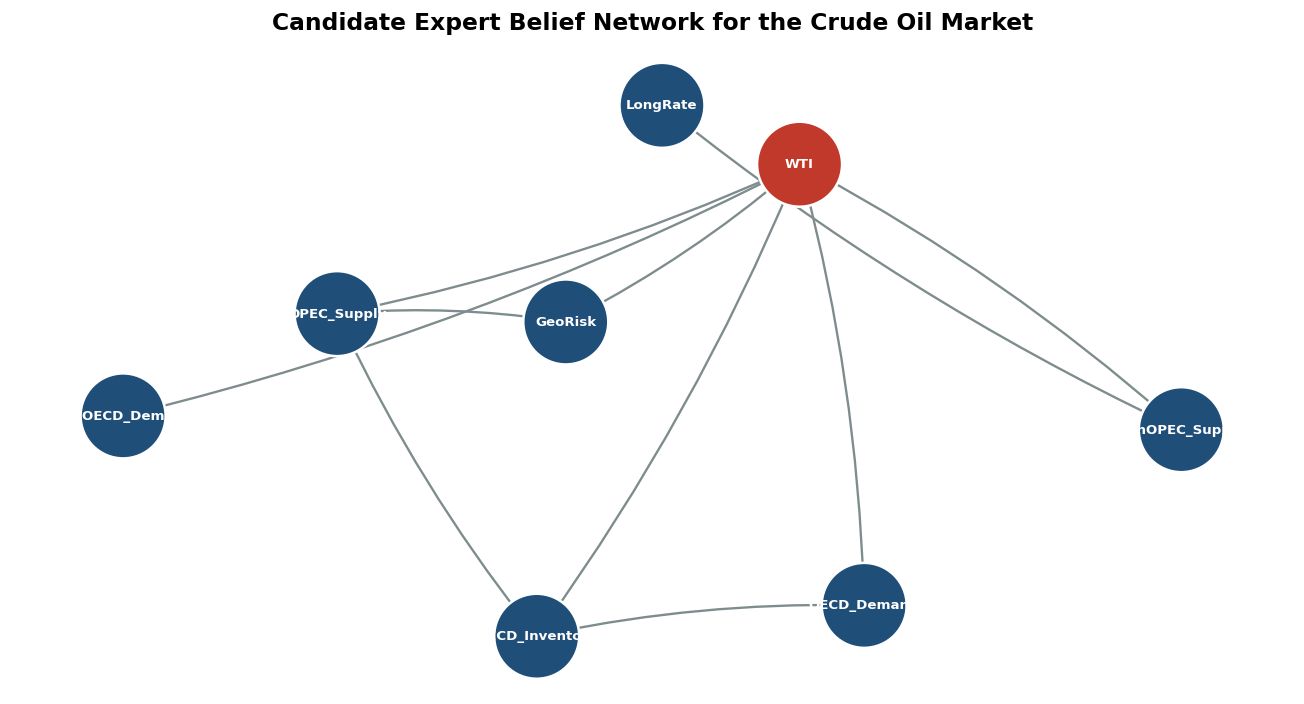

Structure learning skipped in this environment: No module named 'pgmpy'


In [19]:
model_vars = ["WTI", "OPEC_Supply", "NonOPEC_Supply", "OECD_Demand",
              "NonOECD_Demand", "OECD_Inventory", "GeoRisk", "LongRate"]
disc = pd.DataFrame(index=master_clean.index)
for v in model_vars:
    disc[v] = pd.qcut(master_clean[v], q=3, labels=["Low", "Med", "High"])
print("Discretised regime frame:", disc.shape)
disc.head(4)

import networkx as nx

expert_edges = [
    ("OPEC_Supply", "WTI"), ("NonOPEC_Supply", "WTI"),
    ("OECD_Demand", "WTI"), ("NonOECD_Demand", "WTI"),
    ("GeoRisk", "WTI"), ("GeoRisk", "OPEC_Supply"),
    ("OECD_Inventory", "WTI"),
    ("OPEC_Supply", "OECD_Inventory"), ("OECD_Demand", "OECD_Inventory"),
    ("LongRate", "NonOPEC_Supply"),
]
G = nx.DiGraph(expert_edges)
pos = nx.spring_layout(G, seed=7, k=1.1)

fig, ax = plt.subplots(figsize=FIGSIZE)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=C["muted"],
                       arrowsize=16, width=1.4, connectionstyle="arc3,rad=0.06")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2600,
                       node_color=["#c0392b" if n == "WTI" else "#1f4e79" for n in G.nodes],
                       edgecolors="white", linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white",
                        font_weight="bold")
ax.set_title("Candidate Expert Belief Network for the Crude Oil Market",
             fontsize=14, fontweight="bold")
ax.axis("off")
plt.show()


learned_edges = []
try:
    from pgmpy.estimators import HillClimbSearch
    try:
        from pgmpy.estimators import BicScore as _Score
    except Exception:
        from pgmpy.estimators import BIC as _Score
    hc = HillClimbSearch(disc)
    best = hc.estimate(scoring_method=_Score(disc), max_indegree=3,
                       max_iter=80, show_progress=False)
    learned_edges = list(best.edges())
    print(f"Learned {len(learned_edges)} directed edges via hill climbing:")
    for u, v in learned_edges:
        print(f"   {u} -> {v}")
except Exception as exc:
    print("Structure learning skipped in this environment:", exc)

if learned_edges:
    Gl = nx.DiGraph(learned_edges)
    posl = nx.spring_layout(Gl, seed=11, k=1.2)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    nx.draw_networkx_edges(Gl, posl, ax=ax, edge_color=C["accent"],
                           arrowsize=16, width=1.4,
                           connectionstyle="arc3,rad=0.06")
    nx.draw_networkx_nodes(Gl, posl, ax=ax, node_size=2600,
                           node_color=["#c0392b" if n == "WTI" else "#2e9e8f"
                                       for n in Gl.nodes],
                           edgecolors="white", linewidths=1.5)
    nx.draw_networkx_labels(Gl, posl, ax=ax, font_size=8, font_color="white",
                            font_weight="bold")
    ax.set_title("Structure Learned from Data (Hill Climbing, BIC score)",
                 fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.show()

## Conclusion

In [20]:
summary = """
Conclusion

A multi-source oil-market dataset was assembled from yfinance market series,
genuine CPI, and seeded physical-market proxies, then cleaned and explored.
Returns are heavy-tailed with strong volatility clustering, the price level is
non-stationary while returns are stationary, and cross-asset correlations are
unstable. The discretised regimes and the candidate belief network provide the
foundation for the structure learning and inference of GWP2.
"""
print(summary)


Conclusion

A multi-source oil-market dataset was assembled from yfinance market series,
genuine CPI, and seeded physical-market proxies, then cleaned and explored.
Returns are heavy-tailed with strong volatility clustering, the price level is
non-stationary while returns are stationary, and cross-asset correlations are
unstable. The discretised regimes and the candidate belief network provide the
foundation for the structure learning and inference of GWP2.

